In [8]:
pip install pytesseract # 

  Using cached pytesseract-0.3.13-py3-none-any.whl.metadata (11 kB)
Using cached pytesseract-0.3.13-py3-none-any.whl (14 kB)

[notice] A new release of pip is available: 25.1.1 -> 25.2
[notice] To update, run: pip3.13 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [6]:
from telethon import TelegramClient # Импортируем основной класс для работы с Telegram API
import os

# Удаляем старые сессионные файлы
session_files = ['ocr_lab_session.session', 'test_session.session', 'ocr_lab_session_new.session', 'ocr_lab_session_fresh.session']
for session_file in session_files:
    if os.path.exists(session_file):
        os.remove(session_file)
        print(f"Удален сессионный файл: {session_file}")

API_ID = 26458868
API_HASH = 'aa9a2adb662b16f426e8b5e251926c6d'

async def main(): # Асинхронная основная функция программы
    async with TelegramClient('ocr_lab_session_fresh', API_ID, API_HASH) as client:
       # Запускаем процесс авторизации клиента,если сессия новая, запросит номер телефона и код подтверждения
        await client.start()
        
        me = await client.get_me() # Получаем информацию о текущем авторизованном пользователе
        print(f"Успешный вход как: {me.first_name}")
        
        # Скачиваем изображения
        try:
            channel = await client.get_entity('asia_bilet')    # Получаем объект канала по его username или ID
            print(f"Канал найден: {channel.title}")
            
            os.makedirs('lab_images_tg_channel', exist_ok=True)
            image_count = 0
            
            async for message in client.iter_messages(channel, limit=150):   # Асинхронно итерируемся по сообщениям канала
            # limit=150 - ограничение на количество проверяемых сообщений 
                if message.photo and image_count < 100:
                    filename = f'lab_images_tg_channel/image_{image_count:03d}.jpg'
                    await client.download_media(message, file=filename)   # Скачиваем медиа-вложение из сообщения в указанный файл
                    print(f'Скачано: {filename}')
                    image_count += 1
                    
            print(f'Скачано {image_count} изображений')
            
        except Exception as e:
            print(f"Ошибка: {e}")

await main()

Удален сессионный файл: ocr_lab_session_fresh.session


Please enter your phone (or bot token):  +79136978301
Please enter the code you received:  82687


Signed in successfully as Veronika K; remember to not break the ToS or you will risk an account ban!
Успешный вход как: Veronika
Канал найден: Билеты и туры в Азию: Таиланд, Вьетнам, Китай, Бали и другие
Скачано: lab_images_tg_channel/image_000.jpg
Скачано: lab_images_tg_channel/image_001.jpg
Скачано: lab_images_tg_channel/image_002.jpg
Скачано: lab_images_tg_channel/image_003.jpg
Скачано: lab_images_tg_channel/image_004.jpg
Скачано: lab_images_tg_channel/image_005.jpg
Скачано: lab_images_tg_channel/image_006.jpg
Скачано: lab_images_tg_channel/image_007.jpg
Скачано: lab_images_tg_channel/image_008.jpg
Скачано: lab_images_tg_channel/image_009.jpg
Скачано: lab_images_tg_channel/image_010.jpg
Скачано: lab_images_tg_channel/image_011.jpg
Скачано: lab_images_tg_channel/image_012.jpg
Скачано: lab_images_tg_channel/image_013.jpg
Скачано: lab_images_tg_channel/image_014.jpg
Скачано: lab_images_tg_channel/image_015.jpg
Скачано: lab_images_tg_channel/image_016.jpg
Скачано: lab_images_tg_channel/

ЗАПУСК OCR ОБРАБОТКИ 100 ИЗОБРАЖЕНИЙ c ТГ КАНАЛА
Обработано: image_000.jpg | Символов: 73 | Слов: 13
Обработано: image_001.jpg | Символов: 218 | Слов: 44
Обработано: image_002.jpg | Символов: 72 | Слов: 15
Обработано: image_003.jpg | Символов: 86 | Слов: 18
Обработано: image_004.jpg | Символов: 78 | Слов: 17
Обработано: image_005.jpg | Символов: 73 | Слов: 15
Обработано: image_006.jpg | Символов: 68 | Слов: 15
Обработано: image_007.jpg | Символов: 246 | Слов: 47
Обработано: image_008.jpg | Символов: 95 | Слов: 20
Обработано: image_009.jpg | Символов: 70 | Слов: 12
Обработано: image_010.jpg | Символов: 265 | Слов: 52
Обработано: image_011.jpg | Символов: 84 | Слов: 17
Обработано: image_012.jpg | Символов: 247 | Слов: 51
Обработано: image_013.jpg | Символов: 143 | Слов: 33
Обработано: image_014.jpg | Символов: 103 | Слов: 24
Обработано: image_015.jpg | Символов: 108 | Слов: 24
Обработано: image_016.jpg | Символов: 96 | Слов: 23
Обработано: image_017.jpg | Символов: 103 | Слов: 22
Обработ

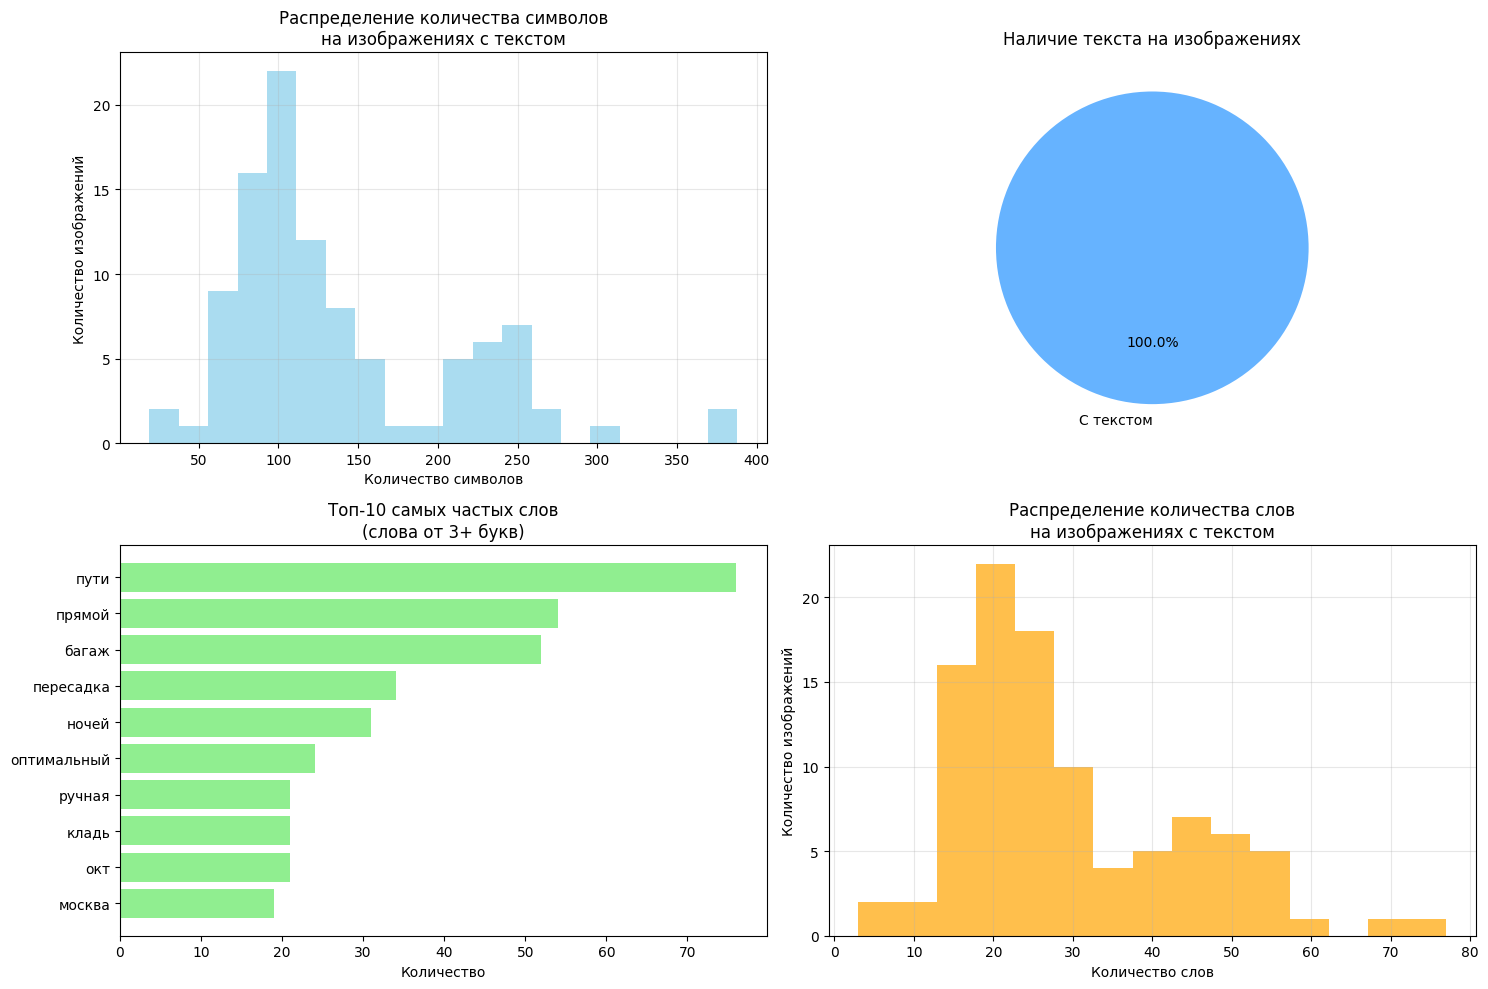

Визуализации сохранены в tg_channel_ocr_analysis_plot.png


In [11]:
import pytesseract
from PIL import Image
import pandas as pd
import os
import matplotlib.pyplot as plt
from collections import Counter
import re


def process_ocr_on_images():
    """Обрабатываем все скачанные изображения через OCR"""
  
    results = []
    successful_images = 0
    
    # Обрабатываем все изображения в папке
    for filename in sorted(os.listdir('lab_images_tg_channel')):
        if filename.endswith(('.jpg')):
            try:
                # Открываем изображение
                image_path = os.path.join('lab_images_tg_channel', filename)
                image = Image.open(image_path)
                
                # OCR распознавание
                text = pytesseract.image_to_string(image, lang='rus+eng')
                text_clean = text.strip()
                
                # Считаем статистику
                char_count = len(text_clean)
                word_count = len(text_clean.split())
                line_count = text_clean.count('\n') + 1 if text_clean else 0
                
                results.append({
                    'filename': filename,
                    'text': text_clean,
                    'char_count': char_count,
                    'word_count': word_count,
                    'line_count': line_count,
                    'has_text': char_count > 0  # Есть ли вообще текст на изображении
                })
                
                successful_images += 1
                print(f"Обработано: {filename} | Символов: {char_count} | Слов: {word_count}")
                
            except Exception as e:
                print(f"Ошибка с {filename}: {e}")
                results.append({
                    'filename': filename,
                    'text': '',
                    'char_count': 0,
                    'word_count': 0,
                    'line_count': 0,
                    'has_text': False
                })
    
    return results, successful_images

def analyze_ocr_results(results):
    """Анализируем результаты OCR с фильтрацией"""
    
    df = pd.DataFrame(results)
    
    print("\n" + "="*60)
    print("АНАЛИЗ РЕЗУЛЬТАТОВ OCR")
    print("="*60)
    
    # Основная статистика
    total_images = len(df)
    images_with_text = df['has_text'].sum()
    total_chars = df['char_count'].sum()
    total_words = df['word_count'].sum()
    
    print(f"Всего изображений: {total_images}")
    print(f"Изображений с текстом: {images_with_text} ({images_with_text/total_images*100:.1f}%)")
    print(f"Всего символов: {total_chars}")
    print(f"Всего слов: {total_words}")
    print(f"Среднее символов на изображение: {df['char_count'].mean():.1f}")
    print(f"Среднее слов на изображение: {df['word_count'].mean():.1f}")
    
    # Топ изображений по количеству текста
    print(f"\nТОП-5 изображений по количеству текста:")
    top_images = df.nlargest(5, 'char_count')[['filename', 'char_count', 'word_count']]
    for _, row in top_images.iterrows():
        print(f"   {row['filename']}: {row['char_count']} символов, {row['word_count']} слов")
    
    # АНАЛИЗ СОДЕРЖИМОГО ТЕКСТА
    all_text = ' '.join(df['text'].tolist())
    
    # фильтрация слов
    words = re.findall(r'\b[a-zA-Zа-яА-Я][a-zA-Zа-яА-Я-]{2,}\b', all_text.lower())
    
    # Расширенный список стоп-слов
    stop_words = {
        # Русские предлоги и союзы
        'в', 'на', 'с', 'по', 'к', 'у', 'о', 'об', 'из', 'от', 'до', 'за', 'же', 'ли', 'бы', 'то',
        'не', 'но', 'а', 'и', 'или', 'да', 'что', 'как', 'для', 'при', 'про', 'со', 'во', 'ко',
        'без', 'над', 'под', 'перед', 'через', 'около', 'после', 'потом', 'тогда', 'здесь', 'там',
        'это', 'тот', 'этот', 'такой', 'какой', 'который', 'свой', 'мой', 'твой', 'наш', 'ваш',
        'их', 'его', 'ее', 'их', 'все', 'всё', 'весь', 'каждый', 'любой', 'некоторый',
        
        # Английские стоп-слова
        'the', 'a', 'an', 'and', 'or', 'but', 'in', 'on', 'at', 'to', 'for', 'of', 'with', 'by',
        'is', 'are', 'was', 'were', 'be', 'been', 'have', 'has', 'had', 'do', 'does', 'did',
        
        # Короткие слова и аббревиатуры
        'шт', 'м', 'см', 'мм', 'кг', 'г', 'л', 'мл', 'руб', 'дол', 'евро', 'usd', 'eur', 'р',
    }
    
    # Фильтруем слова
    filtered_words = []
    for word in words:
        # Убираем слова из стоп-листа
        if word in stop_words:
            continue
        # Убираем слова, содержащие цифры
        if any(char.isdigit() for char in word):
            continue
        # Убираем слишком короткие слова (после обработки дефисов)
        clean_word = word.replace('-', '')
        if len(clean_word) < 3:
            continue
        filtered_words.append(word)
    
    word_freq = Counter(filtered_words)
    
    print(f"\nСТАТИСТИКА ФИЛЬТРАЦИИ СЛОВ:")
    print(f"   Всего слов найдено: {len(words)}")
    print(f"   После фильтрации: {len(filtered_words)}")
    print(f"   Уникальных слов: {len(word_freq)}")
    
    print(f"\nСАМЫЕ ЧАСТЫЕ СЛОВА (после фильтрации):")
    if word_freq:
        top_words = word_freq.most_common(15)
        max_word_len = max(len(word) for word, _ in top_words)
        
        for i, (word, count) in enumerate(top_words, 1):
            # Красивое форматирование
            padding = ' ' * (max_word_len - len(word))
            print(f"   {i:2d}. {word}{padding} : {count:3d} раз")
            
        # Дополнительная информация о тексте
        print(f"\n ДОПОЛНИТЕЛЬНАЯ ИНФОРМАЦИЯ:")
        print(f"   Самое длинное слово: {max(filtered_words, key=len) if filtered_words else 'нет'}")
        
        # Средняя длина слов
        if filtered_words:
            avg_word_len = sum(len(word) for word in filtered_words) / len(filtered_words)
            print(f"   Средняя длина слова: {avg_word_len:.1f} символов")
            
    else:
        print("   Не найдено подходящих слов после фильтрации")
    
    return df

def save_detailed_results(df):
    """Сохраняем детальные результаты в tg_channel_ocr_detailed_results.csv"""
    
    # Сохраняем в CSV
    csv_filename = 'tg_channel_ocr_detailed_results.csv'
    df.to_csv(csv_filename, index=False, encoding='utf-8')
    
    print(f"\nРезультаты сохранены в {csv_filename} (таблица с данными)")
 

def create_visualizations(df):
    """Создаем визуализации результатов"""
    
    try:
        # Создаем фигуру с несколькими subplots
        fig, axes = plt.subplots(2, 2, figsize=(15, 10))
        
        # График 1: Распределение количества символов (если есть текст)
        images_with_text = df[df['char_count'] > 0]
        if len(images_with_text) > 0:
            axes[0, 0].hist(images_with_text['char_count'], bins=20, alpha=0.7, color='skyblue')
            axes[0, 0].set_title('Распределение количества символов\nна изображениях с текстом')
            axes[0, 0].set_xlabel('Количество символов')
            axes[0, 0].set_ylabel('Количество изображений')
            axes[0, 0].grid(True, alpha=0.3)
        else:
            axes[0, 0].text(0.5, 0.5, 'Нет изображений с текстом', 
                           ha='center', va='center', transform=axes[0, 0].transAxes, fontsize=12)
            axes[0, 0].set_title('Распределение символов')
        
        # График 2: Круговая диаграмма наличия текста
        text_presence = df['has_text'].value_counts()
        colors = ['#66b3ff', '#ff9999']
        
        if len(text_presence) == 2:
            labels = ['С текстом', 'Без текста']
            axes[0, 1].pie(text_presence.values, labels=labels, autopct='%1.1f%%', 
                          colors=colors, startangle=90)
        elif len(text_presence) == 1:
            if text_presence.index[0]:
                labels = ['С текстом']
                axes[0, 1].pie(text_presence.values, labels=labels, autopct='%1.1f%%', 
                              colors=[colors[0]], startangle=90)
            else:
                labels = ['Без текста']
                axes[0, 1].pie(text_presence.values, labels=labels, autopct='%1.1f%%', 
                              colors=[colors[1]], startangle=90)
        else:
            axes[0, 1].text(0.5, 0.5, 'Нет данных', 
                           ha='center', va='center', transform=axes[0, 1].transAxes, fontsize=12)
        
        axes[0, 1].set_title('Наличие текста на изображениях')
        
        # График 3: Топ слов (если есть текст)
        if len(images_with_text) > 0:
            all_text = ' '.join(images_with_text['text'].tolist())
            words = re.findall(r'\b[a-zA-Zа-яА-Я][a-zA-Zа-яА-Я-]{2,}\b', all_text.lower())
            
            # Фильтрация
            stop_words = {'в', 'на', 'с', 'по', 'к', 'у', 'о', 'из', 'от', 'за', 'не', 'но', 'а', 'и', 'или'}
            words = [word for word in words if word not in stop_words and not any(char.isdigit() for char in word)]
            
            word_freq = Counter(words)
            
            if word_freq:
                top_words = word_freq.most_common(10)
                words_list, counts = zip(*top_words)
                
                axes[1, 0].barh(words_list, counts, color='lightgreen')
                axes[1, 0].set_title('Топ-10 самых частых слов\n(слова от 3+ букв)')
                axes[1, 0].set_xlabel('Количество')
                axes[1, 0].invert_yaxis()
        
        # График 4: Распределение по количеству слов
        if len(images_with_text) > 0:
            axes[1, 1].hist(images_with_text['word_count'], bins=15, alpha=0.7, color='orange')
            axes[1, 1].set_title('Распределение количества слов\nна изображениях с текстом')
            axes[1, 1].set_xlabel('Количество слов')
            axes[1, 1].set_ylabel('Количество изображений')
            axes[1, 1].grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.savefig('tg_channel_ocr_analysis_plot.png', dpi=150, bbox_inches='tight')
        plt.show()
        
        print("Визуализации сохранены в tg_channel_ocr_analysis_plot.png")
        
    except Exception as e:
        print(f"Ошибка при создании графиков: {e}")

# ЗАПУСКАЕМ ВЕСЬ ПРОЦЕСС OCR
if __name__ == '__main__':
    print("ЗАПУСК OCR ОБРАБОТКИ 100 ИЗОБРАЖЕНИЙ c ТГ КАНАЛА")
    print("="*60)
    
    # 1. OCR распознавание
    results, successful = process_ocr_on_images()
    
    if successful > 0:
        # 2. Анализ результатов
        df = analyze_ocr_results(results)
        
        # 3. Сохранение результатов
        save_detailed_results(df)
        
        # 4. Визуализации
        create_visualizations(df)


In [24]:
# OCR АНАЛИЗ С ЛЕММАТИЗАЦИЕЙ
import pytesseract                      # OCR движок
from PIL import Image                   # работа с изображениями
import pandas as pd                     # анализ данных
import os                               # работа с файловой системой
import pymorphy3                        # морфологический анализ русского языка
from collections import Counter         # подсчет частоты
import re                               # регулярные выражения

def lemmatize_russian_text(words):
    """Лемматизация русских слов - приведение к начальной форме"""
    morph = pymorphy3.MorphAnalyzer()   # создаем анализатор
    lemmatized_words = []
    
    for word in words:
        parsed = morph.parse(word)[0]   # морфологический разбор
        lemma = parsed.normal_form      # нормальная форма слова
        lemmatized_words.append(lemma)
    
    return lemmatized_words

def process_ocr_on_images():
    """Обработка всех изображений через OCR"""
    results = []                        # список для результатов
    successful_images = 0               # счетчик успешных обработок
    
    for filename in sorted(os.listdir('lab_images_tg_channel')):  # итерация по файлам
        if filename.endswith(('.jpg', '.png', '.jpeg')):          # проверка формата
            try:
                image_path = os.path.join('lab_images_tg_channel', filename)  # полный путь
                image = Image.open(image_path)                    # открываем изображение
                
                text = pytesseract.image_to_string(image, lang='rus+eng')  # OCR распознавание
                text_clean = text.strip()                         # очистка текста
                
                char_count = len(text_clean)                      # подсчет символов
                word_count = len(text_clean.split())              # подсчет слов
                line_count = text_clean.count('\n') + 1 if text_clean else 0  # подсчет строк
                
                results.append({                                   # сохранение результатов
                    'filename': filename,
                    'text': text_clean,
                    'char_count': char_count,
                    'word_count': word_count,
                    'line_count': line_count,
                    'has_text': char_count > 0
                })
                
                successful_images += 1                            # инкремент счетчика
                print(f"Обработано: {filename} | Символов: {char_count} | Слов: {word_count}")
                
            except Exception as e:
                print(f"Ошибка с {filename}: {e}")               # обработка ошибок
                results.append({                                  # запись с нулевыми результатами
                    'filename': filename, 'text': '', 'char_count': 0,
                    'word_count': 0, 'line_count': 0, 'has_text': False
                })
    
    return results, successful_images

def analyze_ocr_results(results):
    """Анализ результатов OCR с лемматизацией"""
    df = pd.DataFrame(results)           # создание DataFrame
    
    print("\n" + "="*60)
    print("АНАЛИЗ РЕЗУЛЬТАТОВ OCR")
    print("="*60)
    
    # Основная статистика
    total_images = len(df)               # всего изображений
    images_with_text = df['has_text'].sum()  # изображений с текстом
    total_chars = df['char_count'].sum() # всего символов
    total_words = df['word_count'].sum() # всего слов
    
    print(f"Всего изображений: {total_images}")
    print(f"Изображений с текстом: {images_with_text} ({images_with_text/total_images*100:.1f}%)")
    print(f"Всего символов: {total_chars}")
    print(f"Всего слов: {total_words}")
    print(f"Среднее символов на изображение: {df['char_count'].mean():.1f}")
    print(f"Среднее слов на изображение: {df['word_count'].mean():.1f}")
    
    # Топ изображений по количеству текста
    print(f"\nТОП-5 изображений по количеству текста:")
    top_images = df.nlargest(5, 'char_count')[['filename', 'char_count', 'word_count']]  # выбор топ-5
    for _, row in top_images.iterrows():                    # вывод информации
        print(f"   {row['filename']}: {row['char_count']} символов, {row['word_count']} слов")
    
    # Анализ текстового содержимого с лемматизацией
    all_text = ' '.join(df['text'].tolist())               # объединение всего текста
    
    words = re.findall(r'\b[a-zA-Zа-яА-Я][a-zA-Zа-яА-Я-]{2,}\b', all_text.lower())  # поиск слов
    
    # Разделение русских и английских слов
    russian_words = [word for word in words if re.match(r'^[а-яА-Я-]+$', word)]  # русские слова
    english_words = [word for word in words if re.match(r'^[a-zA-Z-]+$', word)]  # английские слова
    
    # Лемматизация русских слов
    if russian_words:
        try:
            russian_lemmas = lemmatize_russian_text(russian_words)  # лемматизация
            print(f"\nЛемматизация: обработано {len(russian_words)} русских слов")
        except Exception as e:
            print(f"Ошибка лемматизации: {e}")
            russian_lemmas = russian_words  # fallback на исходные слова
    else:
        russian_lemmas = []
    
    english_lemmas = english_words                            # английские слова без изменений
    all_lemmas = russian_lemmas + english_lemmas              # объединение всех лемм
    
    # Список стоп-слов
    stop_words = {
        'в', 'на', 'с', 'по', 'к', 'у', 'о', 'об', 'из', 'от', 'до', 'за', 'же', 'ли', 'бы', 'то',
        'не', 'но', 'а', 'и', 'или', 'да', 'что', 'как', 'для', 'при', 'про', 'со', 'во', 'ко',
        'без', 'над', 'под', 'перед', 'через', 'около', 'после', 'потом', 'тогда', 'здесь', 'там',
        'это', 'тот', 'этот', 'такой', 'какой', 'который', 'свой', 'мой', 'твой', 'наш', 'ваш',
        'их', 'его', 'ее', 'все', 'весь', 'каждый', 'любой', 'некоторый',
        'the', 'a', 'an', 'and', 'or', 'but', 'in', 'on', 'at', 'to', 'for', 'of', 'with', 'by',
        'is', 'are', 'was', 'were', 'be', 'been', 'have', 'has', 'had', 'do', 'does', 'did',
        'шт', 'м', 'см', 'мм', 'кг', 'г', 'л', 'мл', 'руб', 'дол', 'евро', 'usd', 'eur', 'р',
    }
    
    # Фильтрация лемм
    filtered_lemmas = []
    for lemma in all_lemmas:
        if lemma in stop_words: continue                     # пропуск стоп-слов
        if any(char.isdigit() for char in lemma): continue   # пропуск слов с цифрами
        clean_lemma = lemma.replace('-', '')                 # удаление дефисов
        if len(clean_lemma) < 3: continue                    # пропуск коротких слов
        filtered_lemmas.append(lemma)                        # добавление в результат
    
    lemma_freq = Counter(filtered_lemmas)                    # подсчет частоты лемм
    
    print(f"\nСТАТИСТИКА ФИЛЬТРАЦИИ СЛОВ:")
    print(f"   Всего слов найдено: {len(words)}")
    print(f"   После лемматизации и фильтрации: {len(filtered_lemmas)}")
    print(f"   Уникальных лемм: {len(lemma_freq)}")
    
    print(f"\nСАМЫЕ ЧАСТЫЕ СЛОВА (после лемматизации):")
    if lemma_freq:
        top_lemmas = lemma_freq.most_common(15)              # топ-15 лемм
        max_lemma_len = max(len(lemma) for lemma, _ in top_lemmas)  # макс длина для форматирования
        
        for i, (lemma, count) in enumerate(top_lemmas, 1):
            padding = ' ' * (max_lemma_len - len(lemma))     # выравнивание
            print(f"   {i:2d}. {lemma}{padding} : {count:3d} раз")
            
        print(f"\nДОПОЛНИТЕЛЬНАЯ ИНФОРМАЦИЯ:")
        print(f"   Самое длинное слово: {max(filtered_lemmas, key=len) if filtered_lemmas else 'нет'}")
        
        if filtered_lemmas:
            avg_lemma_len = sum(len(lemma) for lemma in filtered_lemmas) / len(filtered_lemmas)
            print(f"   Средняя длина слова: {avg_lemma_len:.1f} символов")
    else:
        print("   Не найдено подходящих слов после фильтрации")

    top_lemmas = lemma_freq.most_common(10) if lemma_freq else []  # получаем топ-10 лемм
    
    return df, top_lemmas  # возвращаем ДВА значения

def save_detailed_results(df):
    """Сохранение результатов анализа"""
    csv_filename = 'tg_channel_ocr_detailed_results.csv'     # имя файла
    df.to_csv(csv_filename, index=False, encoding='utf-8')   # сохранение в CSV
    print(f"\nРезультаты сохранены в {csv_filename}")

print("ЗАПУСК OCR ОБРАБОТКИ ИЗОБРАЖЕНИЙ С ТГ КАНАЛА")
print("="*60)
    
# 1. OCR распознавание
results, successful = process_ocr_on_images() # обработка изображений

if successful > 0:
    # 2. Анализ результатов (распаковываем кортеж)
    df, top_lemmas = analyze_ocr_results(results)  # распаковываем кортеж (df, top_lemmas)
    
    # 3. Сохранение результатов 
    save_detailed_results(df)  # передаем только DataFrame    

ЗАПУСК OCR ОБРАБОТКИ ИЗОБРАЖЕНИЙ С ТГ КАНАЛА
Обработано: image_000.jpg | Символов: 73 | Слов: 13
Обработано: image_001.jpg | Символов: 218 | Слов: 44
Обработано: image_002.jpg | Символов: 72 | Слов: 15
Обработано: image_003.jpg | Символов: 86 | Слов: 18
Обработано: image_004.jpg | Символов: 78 | Слов: 17
Обработано: image_005.jpg | Символов: 73 | Слов: 15
Обработано: image_006.jpg | Символов: 68 | Слов: 15
Обработано: image_007.jpg | Символов: 246 | Слов: 47
Обработано: image_008.jpg | Символов: 95 | Слов: 20
Обработано: image_009.jpg | Символов: 70 | Слов: 12
Обработано: image_010.jpg | Символов: 265 | Слов: 52
Обработано: image_011.jpg | Символов: 84 | Слов: 17
Обработано: image_012.jpg | Символов: 247 | Слов: 51
Обработано: image_013.jpg | Символов: 143 | Слов: 33
Обработано: image_014.jpg | Символов: 103 | Слов: 24
Обработано: image_015.jpg | Символов: 108 | Слов: 24
Обработано: image_016.jpg | Символов: 96 | Слов: 23
Обработано: image_017.jpg | Символов: 103 | Слов: 22
Обработано:

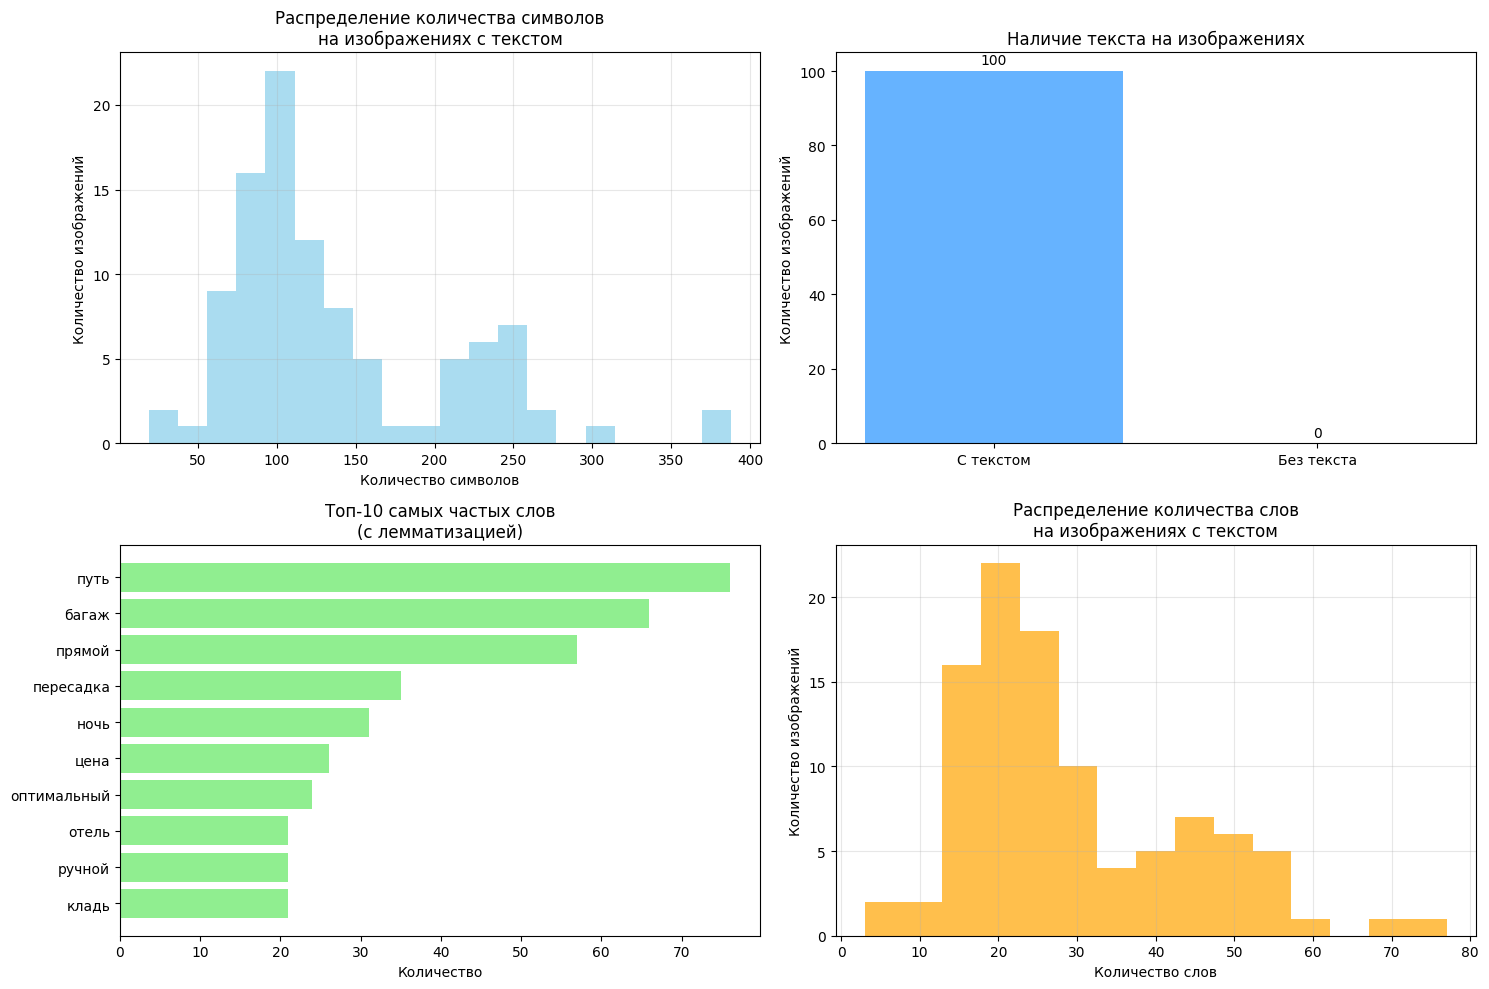

Визуализации с лемматизацией сохранены в tg_channel_ocr_analysis_plot.png


In [27]:
def create_visualizations(df, top_lemmas=None):
    """Создание визуализаций на основе готовых результатов анализа"""
    
    try:
        fig, axes = plt.subplots(2, 2, figsize=(15, 10))    # создание сетки графиков 2x2
        
        # График 1: Распределение количества символов
        images_with_text = df[df['char_count'] > 0]         # фильтрация изображений с текстом
        if len(images_with_text) > 0:
            axes[0, 0].hist(images_with_text['char_count'], bins=20, alpha=0.7, color='skyblue')  # гистограмма
            axes[0, 0].set_title('Распределение количества символов\nна изображениях с текстом')  # заголовок
            axes[0, 0].set_xlabel('Количество символов')    # подпись оси X
            axes[0, 0].set_ylabel('Количество изображений') # подпись оси Y
            axes[0, 0].grid(True, alpha=0.3)                # включение сетки
        else:
            axes[0, 0].text(0.5, 0.5, 'Нет изображений с текстом',   # текст при отсутствии данных
                           ha='center', va='center', transform=axes[0, 0].transAxes, fontsize=12)
            axes[0, 0].set_title('Распределение символов')
        
        # График 2: Столбчатая диаграмма наличия текста
        text_presence = df['has_text'].value_counts().reindex([True, False], fill_value=0)
        labels = ['С текстом', 'Без текста']
        colors = ['#66b3ff', '#ff9999']
        
        axes[0, 1].bar(labels, text_presence.values, color=colors)
        axes[0, 1].set_ylabel('Количество изображений')
        axes[0, 1].set_title('Наличие текста на изображениях')
        
        # Добавление значений над столбцами (опционально)
        for i, v in enumerate(text_presence.values):
            axes[0, 1].text(i, v + max(text_presence.values) * 0.01, str(v), ha='center', va='bottom')
                
        # График 3: Топ слов ИСПОЛЬЗУЕТ ГОТОВЫЕ ДАННЫЕ ИЗ АНАЛИЗА
        if top_lemmas and len(top_lemmas) > 0:
            lemmas_list, counts = zip(*top_lemmas)          # распаковываем готовые данные
            axes[1, 0].barh(lemmas_list, counts, color='lightgreen')  # строим график
            axes[1, 0].set_title('Топ-10 самых частых слов\n(с лемматизацией)')
            axes[1, 0].set_xlabel('Количество')             # подпись оси X
            axes[1, 0].invert_yaxis()                       # инверсия оси Y для правильного порядка
        else:
            axes[1, 0].text(0.5, 0.5, 'Нет данных о словах',  # если данных нет
                           ha='center', va='center', transform=axes[1, 0].transAxes, fontsize=12)
            axes[1, 0].set_title('Топ слов')                # заголовок
        
        # График 4: Распределение количества слов
        if len(images_with_text) > 0:
            axes[1, 1].hist(images_with_text['word_count'], bins=15, alpha=0.7, color='orange')  # гистограмма
            axes[1, 1].set_title('Распределение количества слов\nна изображениях с текстом')  # заголовок
            axes[1, 1].set_xlabel('Количество слов')        # подпись оси X
            axes[1, 1].set_ylabel('Количество изображений') # подпись оси Y
            axes[1, 1].grid(True, alpha=0.3)                # включение сетки
        else:
            axes[1, 1].text(0.5, 0.5, 'Нет изображений с текстом',   # если нет данных
                           ha='center', va='center', transform=axes[1, 1].transAxes, fontsize=12)
            axes[1, 1].set_title('Распределение слов')      # заголовок
        
        plt.tight_layout()                                  # автоматическое размещение графиков
        plt.savefig('tg_channel_ocr_analysis_plot.png', dpi=150, bbox_inches='tight')  # сохранение графика
        plt.show()                                          # отображение графиков
        
        print("Визуализации с лемматизацией сохранены в tg_channel_ocr_analysis_plot.png")
        
    except Exception as e:
        print(f"Ошибка при создании графиков: {e}")

# Вызов функции с передачей top_lemmas
create_visualizations(df, top_lemmas=top_lemmas)
